# 22d — 1-D **FWHM-only** loss: drop the sigma_fit channel

**Series 22 = deeper understanding of the distributions the model generates.** 22b showed that, at the
true parameters, the Monte-Carlo **(FWHM, sigma_fit)** cloud does *not* fully match the real data — the
**uncertainty (sigma_fit) part is the mismatched one** (and 22c showed our estimator's sigma is the
wrong scale). This notebook asks the direct question: **if we stop using the fit uncertainty and fit
only the FWHM distribution (1-D), can the model find the true (mu, gamma) better?**

**One change vs 22a:** the likelihood goes from **2-D `(FWHM, sigma_fit)`** to **1-D `FWHM` only**.
Everything else is 22a verbatim: z-scored per-run reward (`loglik_z`), score denominator = the
experiment's own `sigma_prop`, **no gradient clip** (`CLIP=inf`), **no parameter clamps**, only the
divergence STOP, 14 experiments, `N_RUNS=100`, `N_ITER=30`, init at `0.5 x truth`.

Concretely, in the 1-D arm:
- the KDE kernel is `W = exp(-0.5 (dF/H_F)^2)` — the `dS/H_S` term is **gone**;
- the gamma-score drops the `dsigma/dgamma` term: `dlogG = (dF * dFWHM/dgamma) / H_F / H_REF`;
- the mu reward is the same z-scored `sum_i log W_ij`, now on the FWHM-only `W`;
- **sigma_fit is not used anywhere** in the loss, gradients or reward. The per-scan fit still runs (it
  is what produces the FWHM); we simply never read its uncertainty output.
- `LR_MU_Z` is **re-derived by the same calibration** (`TARGET_STEP = 3.3`), so the only behavioural
  change vs 22a is the dropped channel.

**Why this is a real question, not a formality.** mu is discrete (photon count), so its only gradient
is the REINFORCE score; on real data the count channel is nearly dead (KDE responsibility ~ uniform),
which left the **sigma_fit channel** as mu's only information link (series 19/20, FM#8). If the FWHM
distribution alone carries enough mu information — through its **spread** (fewer photons -> noisier fits
-> broader FWHM cloud) — the 1-D loss may recover mu at least as well. If not, mu will stay pinned near
its 0.5x init and the 1-D loss will look clearly worse.

**Predictions (falsifiable).**
- *Hypothesis (sigma channel is mismatched and may be hurting):* 1-D puts mu closer to truth than 22a's
  **132.5%** rel-RMSE (ideally <= 21i's 40.6%), with gamma roughly unchanged (~18-21%).
- *Counter-hypothesis (FM#8):* the FWHM marginal does not identify mu on its own -> mu freezes at
  ~0.5x truth (ratios -> ~0.5) and rel-RMSE is **worse** than 22a. Either outcome is informative: it
  settles whether the **FWHM-spread channel** (a standing recommendation) is a usable mu signal.

**Reference (22a, 2-D, same 14 exps, 100x30):** mu rel-RMSE 132.5% / bias +74.7%, gamma 18.6%,
0 divergences, 14.9 min.


## Panel (series-22 visual conventions)
- **FIG 1 (interactive, Plotly)** — per power (1nW, then 3nW): the **(mu, gamma) parameter path** (left)
  and the **FWHM distribution** we optimise to (right) — the simulated FWHM draws at the current step
  (filled) against the **real measured FWHM** (red). Experiment **dropdown** + **play button / slider**
  step through the iterations. The path is drawn **from the initialisation (0.5x truth) onward**.
  (The sigma_fit axis is gone: this notebook's loss is FWHM-only.)
- **FIG 2** mu report: `mu_hat/mu_true` with honest Fisher `sigma_mu` whiskers (Fisher now computed on
  the 1-D likelihood).
- **FIG 3** normalised trajectories `mu/mu_true`, `gamma/gamma_true` vs iteration.
- **FIG 4** accuracy vs transmission (mu and gamma ratios, both powers, goal bands).

Figures render **inline only** (no savefig); the notebook is executed **in place**.


In [1]:
# ============================================================
# 22a — imports
# ============================================================
import math, time, os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p); REPO_ROOT = _p; break
os.chdir(REPO_ROOT)

from src.fitting import nll, fwhm_from_theta, fit_profile
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

# --- series-22 interactive viz ---
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from scipy.ndimage import gaussian_filter, gaussian_filter1d

pio.templates.default = 'plotly_white'
pio.renderers.default = os.environ.get('PLOTLY_RENDERER', 'vscode')  # compact mime bundle; renders natively in VS Code / JupyterLab
# (override with e.g. PLOTLY_RENDERER=notebook for a self-contained inline-HTML figure)

print('Imports OK  |  plotly', plotly.__version__)

Imports OK  |  plotly 7.1.0


In [2]:
# ============================================================
# EXPERIMENTS — true values from Gregor's fits (identical to 17f/16-series) + real data file
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393, sigma_prop=2.576, lam=2.232, gamma_true=8.5, n_target=61, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans05.txt'),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372, sigma_prop=3.445, lam=2.122, gamma_true=8.5, n_target=358, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans10.txt'),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316, sigma_prop=4.141, lam=2.286, gamma_true=8.5, n_target=1138, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans20.txt'),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405, sigma_prop=7.198, lam=2.351, gamma_true=8.5, n_target=2428, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans40.txt'),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374, sigma_prop=9.851, lam=2.593, gamma_true=8.5, n_target=2424, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans60.txt'),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365, sigma_prop=12.627, lam=2.758, gamma_true=8.5, n_target=2487, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans80.txt'),
    dict(name='1nW Trans100', power='1nW', mu_true=70.817, sigma_prop=17.221, lam=2.636, gamma_true=8.5, n_target=2455, data_file='data/raw_data/fwhm_1nW_240221/fwhm_1nW_240221SIL_Puppy_hindleg_red1nW_Top20nW_Trans100.txt'),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204, sigma_prop=3.724, lam=2.186, gamma_true=14.1, n_target=252, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans05.txt'),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476, sigma_prop=5.639, lam=2.158, gamma_true=14.1, n_target=1572, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans10.txt'),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279, sigma_prop=8.319, lam=2.264, gamma_true=14.1, n_target=2171, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans20.txt'),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892, sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans40.txt'),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95, lam=2.741, gamma_true=14.1, n_target=2541, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans60.txt'),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans80.txt'),
    dict(name='3nW Trans100', power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516, data_file='data/raw_data/fwhm_3nW_210221/fwhm_3nW_210221SIL_Puppy_hindleg_red3nW_Top20nW_Trans100.txt'),
]
print(f'{len(EXPERIMENTS)} experiments configured')

14 experiments configured


In [3]:
# ============================================================
# 22d CONFIG — ONE change vs 22a: the LIKELIHOOD is 1-D FWHM-only (sigma_fit channel dropped)
#   everything else = 22a: z-scored reward, no clip, no clamps, divergence STOP
# ============================================================
N_RUNS   = 100
N_ITER   = 30
LR_GAMMA = 0.5            # unchanged (raw |grad_gamma| ~ O(1), was never clipped)
SIGMA_REF = 10.0          # kept for reference (score uses the experiment's own sigma_prop)
GAMMA_SCALE = True
H_REF = 1.0
CLIP     = float('inf')   # NO gradient clipping
SEED     = 42
LAMBDA_MEAN = 0.0
MU_GUARD    = 1500.0          # divergence STOP (not a clamp): mu outside (0.2, 1500) -> stop
GAMMA_GUARD = (0.02, 500.0)   # divergence STOP: gamma outside this band -> stop

# ---- 22d: the observable is the FWHM distribution only (no sigma_fit channel, no H_S) ----
LOSS_DIM = 1                  # 1 = FWHM-only; 2 = (FWHM, sigma_fit) as in 22a
REWARD_MODE = 'loglik_z'      # unchanged vs 22a

# ---- LR calibration: match the median mu step to the series reference (TARGET_STEP) ----
TARGET_STEP = 3.3
LR_MU_Z     = None            # <- filled by the calibration cell below

M_FINAL = 500; FISHER_SEEDS = 1; FISHER_BASE_SEED = 7000

SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    N_RUNS, N_ITER, M_FINAL = 10, 5, 50
    EXPERIMENTS = EXPERIMENTS[:3]
    print('*** SMOKE RUN ***')

N_CPUS = os.cpu_count() or 4
N_WORKERS = 4
print(f'config: N_RUNS={N_RUNS}, N_ITER={N_ITER}, loss=1-D FWHM, reward={REWARD_MODE}, clip={CLIP}, workers={N_WORKERS}')


config: N_RUNS=100, N_ITER=30, loss=1-D FWHM, reward=loglik_z, clip=inf, workers=4


In [4]:
# ============================================================
# helpers — 1-D FWHM-only KDE scores + the 22a z-scored reward + generation pass
#   (sigma_fit is never read: the per-scan fit still runs, only its FWHM output is used)
# ============================================================
def _fit_fn(ph): return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th): return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph): return nll(th, ph, model='lorentzian', uniform_bg=False)

def load_target(exp):
    '''Real FWHM data in MHz + the FWHM KDE bandwidth (Scott). 22d: FWHM only.

    The row-validity filter keeps the 15-series convention (finite FWHM, FWHM > 0, and
    fit-error/FWHM < 10) so the same scans are selected as in 22a -- but the fit error itself
    is never used in the likelihood.'''
    d = np.genfromtxt(exp['data_file'])
    fwhm_mhz = d[:, 0] * 1000.0; err_mhz = d[:, 1] * 1000.0
    ok = ~np.isnan(fwhm_mhz) & ~np.isnan(err_mhz) & (fwhm_mhz > 0)
    filt = ok & (err_mhz / fwhm_mhz < 10.0)
    tf = torch.tensor(fwhm_mhz[filt], dtype=torch.float32)
    n = len(tf); sc = n ** (-1.0 / 6.0)
    hf = float(tf.std()) * sc
    return tf, hf

def kde_scores(sim_f, sim_n, sim_df, data_f, h_f, mu, sigma_prop):
    '''1-D FWHM-only KDE: kernel W = exp(-0.5 (dF/H_F)^2).  Returns per-data-point scores.

    s_mu    : REINFORCE mu score, weighted by the FWHM-kernel responsibilities w_ij
    s_gamma : z-form gamma score, (dF * dFWHM/dgamma)/H_F / H_REF   (no sigma term)
    '''
    d_f = data_f[:, None] - sim_f[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        dlogG = (d_f * sim_df[None, :]) / h_f / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    return s_mu, s_gamma, -logp.mean(), w, W

def reward_vector(mode, W):
    '''22a reward: Anuar's per-run log-likelihood of the real data (SUM over data points),
    Z-SCORED across the N_RUNS draws (a per-step adaptive LR 1/std(r)).'''
    r = torch.log(W.clamp_min(1e-30)).sum(dim=0)
    if mode == 'loglik_sum':
        return r
    if mode == 'loglik_z':
        return (r - r.mean()) / (r.std() + 1e-12)
    raise ValueError(mode)

import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE
def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)
def _init_worker(): torch.set_num_threads(1)
def _parallel_map(pool, tasks): return list(pool.map(_run_one, tasks, chunksize=8))

def cloud_at(mu_val, gamma_val, exp, pool, step):
    '''One generation pass at (mu, gamma): the N_RUNS FWHM draws + dFWHM/dgamma.
    (compute_fwhm_and_dgamma also returns sigma_fit / dsigma/dgamma; 22d ignores them.)'''
    sigma_prop, lam = exp['sigma_prop'], exp['lam']
    rng2 = np.random.default_rng(SEED + step)
    tasks, ns = [], []
    for _ in range(N_RUNS):
        u, b, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng2)
        tasks.append((gamma_val, u.numpy(), b.numpy())); ns.append(n)
    res = _parallel_map(pool, tasks)
    ft   = torch.tensor([r[0] for r in res], dtype=torch.float32)
    nt   = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor([r[2] for r in res], dtype=torch.float32)
    return ft, nt, dg_t
print('helpers ready')


helpers ready


In [5]:
# ============================================================
# LR CALIBRATION — match the median mu step to TARGET_STEP (same procedure as 22a), so the only
# behavioural change vs 22a is the dropped sigma channel, not a re-tuned LR.
# ============================================================
def _init_abs_grad_mu(exp, pool):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    mu_val, gamma_val = 0.5 * mu_true, 0.5 * exp['gamma_true']
    target_f, H_F = load_target(exp)
    ft, nt, dg_t = cloud_at(mu_val, gamma_val, exp, pool, step=0)
    _, _, _, _, W = kde_scores(ft, nt, dg_t, target_f, H_F, mu_val, sigma_prop)
    r = reward_vector(REWARD_MODE, W)
    score = (nt - mu_val) / sigma_prop ** 2
    return abs(float(-(r - r.mean()) @ score))

with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
    grads = [_init_abs_grad_mu(e, pool) for e in EXPERIMENTS]
med_grad = float(np.median(grads))
LR_MU_Z  = TARGET_STEP / med_grad
print(f'z-scored |grad_mu| at init across {len(grads)} exps:')
print(f'  min {min(grads):.3g}   median {med_grad:.3g}   max {max(grads):.3g}')
print(f'  TARGET_STEP {TARGET_STEP:.3g}  ->  LR_MU_Z = {LR_MU_Z:.3g}')


z-scored |grad_mu| at init across 14 exps:
  min 0.0423   median 1.22   max 10.5
  TARGET_STEP 3.3  ->  LR_MU_Z = 2.72


In [6]:
# ============================================================
# One experiment (1-D FWHM loss), NO clamps; frames pair each parameter state with the FWHM
# distribution it generated — incl. the initialisation as frame 0 (no skipped step).
# ============================================================
def run_experiment(exp):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    target_f, H_F = load_target(exp)
    mu_val, gamma_val = 0.5 * mu_true, 0.5 * gamma_true

    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'),
              initializer=_init_worker) as pool:
        frames_ = []; t0 = time.time(); diverged = False; diverged_at = None
        for step in range(N_ITER + 1):
            ft, nt, dg_t = cloud_at(mu_val, gamma_val, exp, pool, step)
            s_mu, s_gamma, nll_val, w, W = kde_scores(ft, nt, dg_t, target_f, H_F, mu_val, sigma_prop)
            r = reward_vector(REWARD_MODE, W)
            score = (nt - mu_val) / sigma_prop ** 2
            grad_mu    = float(-(r - r.mean()) @ score)
            grad_gamma = float(-s_gamma.mean())
            frames_.append(dict(step=step, mu=mu_val, gamma=gamma_val, nll=float(nll_val),
                                grad_mu=grad_mu, grad_gamma=grad_gamma,
                                abs_grad_mu=abs(grad_mu), abs_grad_gamma=abs(grad_gamma),
                                mean_n=float(nt.mean()),
                                cloud_f=ft.numpy().copy()))
            if step == N_ITER:
                break
            lr_mu_decay = LR_MU_Z * (1.0 - step / N_ITER)
            mu_val    = mu_val    - lr_mu_decay * grad_mu
            gamma_val = gamma_val - LR_GAMMA * (1.0 - 0.5 * step / N_ITER) * grad_gamma
            if (not (0.2 <= mu_val <= MU_GUARD)) or (not (GAMMA_GUARD[0] <= gamma_val <= GAMMA_GUARD[1])):
                diverged = True; diverged_at = step
                break

        # Fisher / CRB at the fitted point, from the 1-D FWHM-only scores (skipped if diverged)
        if diverged or len(frames_) < 2:
            std_mu = std_g = float('nan')
        else:
            mu_val, gamma_val = frames_[-1]['mu'], frames_[-1]['gamma']
            J_list = []
            for seed in range(FISHER_SEEDS):
                rng = np.random.default_rng(FISHER_BASE_SEED + seed)
                tasks, ns = [], []
                for _ in range(M_FINAL):
                    u, b_, n = draw_fixed_noise(mu_val, sigma_prop, lam, rng)
                    tasks.append((gamma_val, u.numpy(), b_.numpy())); ns.append(n)
                res2 = _parallel_map(pool, tasks)
                ft  = torch.tensor([x[0] for x in res2], dtype=torch.float32)
                nn2 = torch.tensor(ns, dtype=torch.float32)
                dg2 = torch.tensor([x[2] for x in res2], dtype=torch.float32)
                s_mu2, s_g2, _, _, _ = kde_scores(ft, nn2, dg2, target_f, H_F, mu_val, sigma_prop)
                s = torch.stack([s_mu2, s_g2], dim=1)
                J_list.append(s.T @ s / len(target_f))
            J = torch.stack(J_list).mean(dim=0)
            Jinv = torch.linalg.inv(J + 1e-8 * torch.eye(2))
            std_mu = math.sqrt(max(Jinv[0, 0].item(), 0.0)); std_g = math.sqrt(max(Jinv[1, 1].item(), 0.0))

    return dict(exp=exp['name'], power=exp['power'], T=int(exp['name'].split('Trans')[1]),
                mu_true=mu_true, gamma_true=gamma_true, sigma_prop=sigma_prop,
                mu_init=0.5 * mu_true, gamma_init=0.5 * gamma_true,
                mu_final=frames_[-1]['mu'], gamma_final=frames_[-1]['gamma'],
                nll_final=frames_[-1]['nll'], std_mu=std_mu, std_gamma=std_g,
                history=frames_, diverged=diverged, diverged_at=diverged_at,
                target_f=target_f.numpy().copy(), H_F=H_F)

t_all = time.time(); results = []
for exp in EXPERIMENTS:
    r = run_experiment(exp); results.append(r)
    print(f"{exp['name']:>12}: mu {r['mu_true']:7.2f} -> {r['mu_final']:7.2f} (x{r['mu_final']/r['mu_true']:.2f})"
          f" | gamma {r['gamma_true']:5.1f} -> {r['gamma_final']:6.2f} (x{r['gamma_final']/r['gamma_true']:.2f})"
          f" | nll {r['nll_final']:.2f} | diverged={r['diverged']}@{r['diverged_at']}")
print(f'\nTotal: {(time.time()-t_all)/60:.1f} min   |   LR_MU_Z = {LR_MU_Z:.3g}')


 1nW Trans05: mu    9.39 ->   17.04 (x1.81) | gamma   8.5 ->   5.60 (x0.66) | nll 1.25 | diverged=False@None


 1nW Trans10: mu   12.37 ->  119.87 (x9.69) | gamma   8.5 ->   5.55 (x0.65) | nll 1.10 | diverged=False@None


 1nW Trans20: mu   17.32 ->  117.22 (x6.77) | gamma   8.5 ->   6.50 (x0.76) | nll 4.16 | diverged=False@None


 1nW Trans40: mu   38.41 ->   92.40 (x2.41) | gamma   8.5 ->   7.96 (x0.94) | nll 3.26 | diverged=False@None


 1nW Trans60: mu   61.37 ->   88.39 (x1.44) | gamma   8.5 ->   8.14 (x0.96) | nll 2.52 | diverged=False@None


...

 3nW Trans20: mu   34.28 ->   76.31 (x2.23) | gamma  14.1 ->  13.80 (x0.98) | nll 2.93 | diverged=False@None


 3nW Trans40: mu   84.89 ->   84.84 (x1.00) | gamma  14.1 ->  13.06 (x0.93) | nll 2.54 | diverged=False@None


 3nW Trans60: mu  103.20 ->   82.14 (x0.80) | gamma  14.1 ->  14.66 (x1.04) | nll 2.48 | diverged=False@None


 3nW Trans80: mu  137.54 ->  102.84 (x0.75) | gamma  14.1 ->  14.59 (x1.03) | nll 2.31 | diverged=False@None


3nW Trans100: mu  175.71 ->  114.24 (x0.65) | gamma  14.1 ->  14.01 (x0.99) | nll 2.71 | diverged=False@None

Total: 15.0 min   |   LR_MU_Z = 2.72


In [7]:
# ============================================================
# summary table + rel-RMSE / rel-bias  (diverged cells excluded from the aggregates)
# ============================================================
print(f"{'exp':<12} {'mu_true':>8} {'mu_fin':>8} {'x':>6} | {'gam_true':>8} {'gam_fin':>8} {'x':>6} | {'s_mu':>7} {'s_gam':>6}")
print('-' * 84)
for r in results:
    print(f"{r['exp']:<12} {r['mu_true']:>8.2f} {r['mu_final']:>8.2f} {r['mu_final']/r['mu_true']:>6.2f} | "
          f"{r['gamma_true']:>8.1f} {r['gamma_final']:>8.2f} {r['gamma_final']/r['gamma_true']:>6.2f} | "
          f"{r['std_mu']:>7.2f} {r['std_gamma']:>6.2f}")

ok = [r for r in results if not r['diverged']]
rmu = np.array([r['mu_final']/r['mu_true'] - 1 for r in ok])
rg  = np.array([r['gamma_final']/r['gamma_true'] - 1 for r in ok])
print(f'\n=== over {len(ok)}/{len(results)} non-diverged experiments ===')
for lbl, rel in [('mu', rmu), ('gamma', rg)]:
    sq = rel ** 2
    print(f'{lbl:>6}: rel-RMSE={math.sqrt(sq.mean())*100:6.1f}%  rel-bias={rel.mean()*100:+6.1f}%')

exp           mu_true   mu_fin      x | gam_true  gam_fin      x |    s_mu  s_gam
------------------------------------------------------------------------------------
1nW Trans05      9.39    17.04   1.81 |      8.5     5.60   0.66 |   67.64   0.86
1nW Trans10     12.37   119.87   9.69 |      8.5     5.55   0.65 |  416.66   0.48
1nW Trans20     17.32   117.22   6.77 |      8.5     6.50   0.76 |   35.96   0.33
1nW Trans40     38.41    92.40   2.41 |      8.5     7.96   0.94 |   21.37   0.33
1nW Trans60     61.37    88.39   1.44 |      8.5     8.14   0.96 |   32.73   0.52
1nW Trans80     79.36    86.95   1.10 |      8.5     8.25   0.97 |   50.32   0.52
1nW Trans100    70.82    88.21   1.25 |      8.5     8.78   1.03 |   69.04   0.44
3nW Trans05     13.20    98.85   7.49 |     14.1     9.92   0.70 |  627.40   0.32
3nW Trans10     24.48    94.99   3.88 |     14.1    10.69   0.76 |   87.23   0.34
3nW Trans20     34.28    76.31   2.23 |     14.1    13.80   0.98 |   24.24   0.34
3nW Trans40  

In [8]:
# ============================================================
# PLOTLY builder — (mu, gamma) path  |  generated FWHM distribution vs the real FWHM data
#   one figure per power; experiment dropdown + play button + slider over the steps.
#   THE RIGHT PANEL IS THE 1-D FWHM DENSITY (this notebook's loss): the simulated draws at the
#   current (mu, gamma) as a filled curve, against the real measured FWHM as a red line.
#   Payload note: frames update only a PREFIX of the trace list; the per-experiment static
#   traces (init / truth) are written once, on each experiment's step-0 frame.
# ============================================================
def _range1d(v, pct=(1, 99), pad=0.12):
    lo, hi = np.percentile(v, pct); d = max(hi - lo, 1e-6)
    return lo - pad * d, hi + pad * d

def _hist1d(v, xr, nb=40, smooth=1.2):
    H, xe = np.histogram(v, bins=nb, range=xr, density=True)
    if smooth:
        H = gaussian_filter1d(H, smooth)
    return 0.5 * (xe[:-1] + xe[1:]), H

def build_power_figure(results, power):
    rs = sorted([r for r in results if r['power'] == power], key=lambda r: r['T'])
    if not rs:
        print(f'no {power} experiments -> figure skipped'); return None

    franges, pranges = {}, {}
    for r in rs:
        cf = np.concatenate([fr['cloud_f'] for fr in r['history']])
        franges[r['exp']] = _range1d(np.concatenate([cf, r['target_f']]))
        pmus = [fr['mu'] for fr in r['history']] + [r['mu_true'], r['mu_init']]
        pgam = [fr['gamma'] for fr in r['history']] + [r['gamma_true'], r['gamma_init']]
        pranges[r['exp']] = ((0, max(pmus) * 1.05), (0, max(pgam) * 1.05))

    fig = make_subplots(rows=1, cols=2, column_widths=[0.42, 0.58], horizontal_spacing=0.10,
                        subplot_titles=['(mu, gamma) path', 'FWHM distribution — sim (fill) vs real (red)'])
    # trace order matters: frames rewrite a PREFIX; per-experiment static traces come last
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#1d3557', width=2), name='path'), 1, 1)                        # 0
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=12, symbol='x'), name='current'), 1, 1)     # 1
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#457b9d', width=1),
                             fill='tozeroy', fillcolor='rgba(69,123,157,0.35)', name='sim FWHM'), 1, 2)                                  # 2
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#e63946', width=2), name='real FWHM'), 1, 2)                   # 3
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#2a9d8f', size=11, symbol='circle-open',
                                                                     line=dict(width=2)), name='init 0.5x'), 1, 1)                     # 4
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#000000', size=13, symbol='cross'), name='truth'), 1, 1)    # 5

    frames = []
    for r in rs:
        xr = franges[r['exp']]; (px0, px1), (py0, py1) = pranges[r['exp']]
        xd, yd = _hist1d(r['target_f'], xr)
        for fr in r['history']:
            k = fr['step']
            px = [h['mu'] for h in r['history'][:k + 1]]
            py = [h['gamma'] for h in r['history'][:k + 1]]
            xs, ys = _hist1d(fr['cloud_f'], xr)
            data = [go.Scatter(x=px, y=py),
                    go.Scatter(x=[px[-1]], y=[py[-1]]),
                    go.Scatter(x=xs, y=ys),
                    go.Scatter(x=xd, y=yd)]
            if k == 0:   # per-experiment static context, written once per experiment
                data += [go.Scatter(x=[r['mu_init']], y=[r['gamma_init']]),
                         go.Scatter(x=[r['mu_true']], y=[r['gamma_true']])]
            frames.append(go.Frame(name=f"{r['exp']}|{k}", data=data, layout=go.Layout(
                title_text=f"{r['exp']}  —  step {k}/{N_ITER}   (mu x{px[-1]/r['mu_true']:.2f}, gamma x{py[-1]/r['gamma_true']:.2f})",
                xaxis=dict(range=[px0, px1], title='mu (photons)'),
                yaxis=dict(range=[py0, py1], title='gamma (MHz)'),
                xaxis2=dict(range=[xr[0], xr[1]], title='FWHM (MHz)'),
                yaxis2=dict(title='density'),
            )))
    fig.frames = frames

    # put the first experiment's step-0 state on the base traces (so it shows before any click)
    for tr, d in zip(fig.data, frames[0].data):
        for prop in ('x', 'y', 'z'):
            val = getattr(d, prop, None)
            if val is not None:
                setattr(tr, prop, val)

    exps = [r['exp'] for r in rs]
    play  = dict(label='\u25b6 play', method='animate',
                 args=[None, dict(frame=dict(duration=350, redraw=True), fromcurrent=True, transition=dict(duration=0))])
    pause = dict(label='\u275a\u275a pause', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
    dropdown = [dict(label=e, method='animate',
                     args=[[f'{e}|0'], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
                for e in exps]
    steps = [dict(method='animate', label=(e if k == 0 else str(k)),
                  args=[[f'{e}|{k}'], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
             for e in exps for k in range(N_ITER + 1)]
    fig.update_layout(
        height=620, margin=dict(t=120, b=40),
        updatemenus=[
            dict(type='buttons', direction='left', x=0.0, y=1.18, xanchor='left', buttons=[play, pause]),
            dict(type='dropdown', direction='down', x=1.0, y=1.18, xanchor='right',
                 showactive=True, buttons=dropdown, active=0),
        ],
        sliders=[dict(active=0, x=0.0, len=1.0, y=-0.06, currentvalue=dict(prefix=''), steps=steps)],
    )
    return fig

print('build_power_figure ready')


build_power_figure ready


In [9]:
# FIG 1a — 1nW interactive: (mu,gamma) path + FWHM distribution; experiment dropdown + play/slider
fig_1nW = build_power_figure(results, '1nW')
if fig_1nW is not None:
    fig_1nW.show()


In [10]:
# FIG 1b — 3nW interactive: (mu,gamma) path + FWHM distribution; experiment dropdown + play/slider
fig_3nW = build_power_figure(results, '3nW')
if fig_3nW is not None:
    fig_3nW.show()


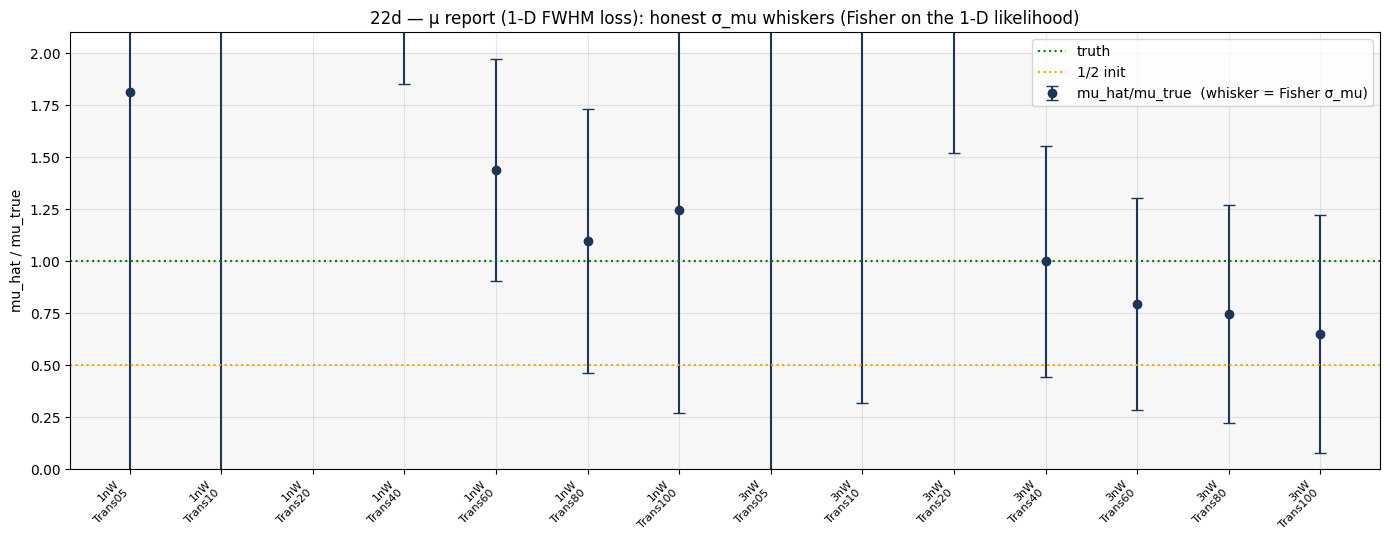

In [11]:
# ============================================================
# FIG 2 — μ report: mu_hat/mu_true with honest Fisher sigma_mu whiskers (per experiment)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5.5))
ys   = [r['mu_final']/r['mu_true'] for r in results]
errs = [r['std_mu']/r['mu_true'] for r in results]
ax.errorbar(np.arange(len(results)), ys, yerr=errs, fmt='o', color='#1d3557', capsize=4, ms=6,
            label='mu_hat/mu_true  (whisker = Fisher σ_mu)')
ax.axhline(1.0, color='g', ls=':', label='truth')
ax.axhline(0.5, color='orange', ls=':', label='1/2 init')
ax.axhspan(0.0, 2.0, color='gray', alpha=0.06)
ax.set_xticks(np.arange(len(results)))
ax.set_xticklabels([r['exp'].replace('nW ', 'nW\n') for r in results], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('mu_hat / mu_true'); ax.set_ylim(0, 2.1)
ax.set_title('22d — μ report (1-D FWHM loss): honest σ_mu whiskers (Fisher on the 1-D likelihood)')
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout(); plt.show()

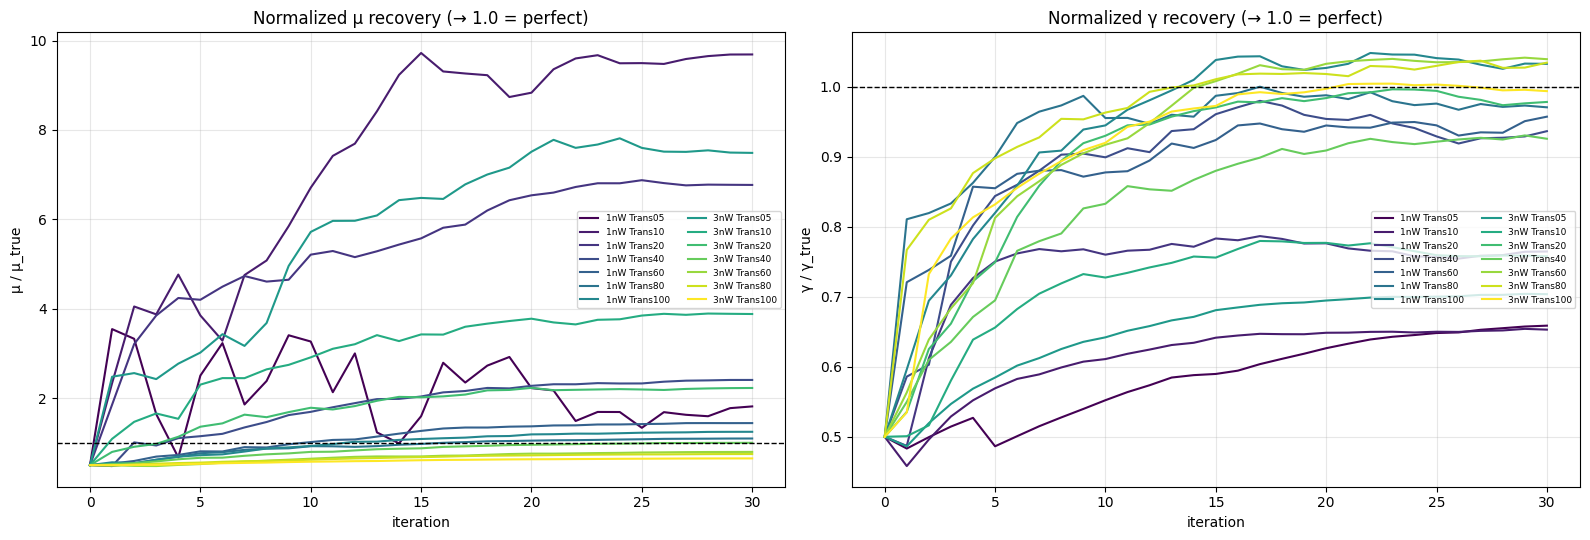

In [12]:
# ============================================================
# FIG 3 — normalized trajectories (μ/μ_true, γ/γ_true vs iteration); starts AT the 0.5x init
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
for r, c in zip(results, colors):
    st = [h['step'] for h in r['history']]
    axes[0].plot(st, [h['mu']    / r['mu_true']    for h in r['history']], color=c, lw=1.5, label=r['exp'])
    axes[1].plot(st, [h['gamma'] / r['gamma_true'] for h in r['history']], color=c, lw=1.5, label=r['exp'])
for ax, yl in [(axes[0], 'μ / μ_true'), (axes[1], 'γ / γ_true')]:
    ax.axhline(1.0, color='k', ls='--', lw=1); ax.set_xlabel('iteration'); ax.set_ylabel(yl); ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, ncol=2, loc='center right')
axes[0].set_title('Normalized μ recovery (→ 1.0 = perfect)')
axes[1].set_title('Normalized γ recovery (→ 1.0 = perfect)')
plt.tight_layout(); plt.show()

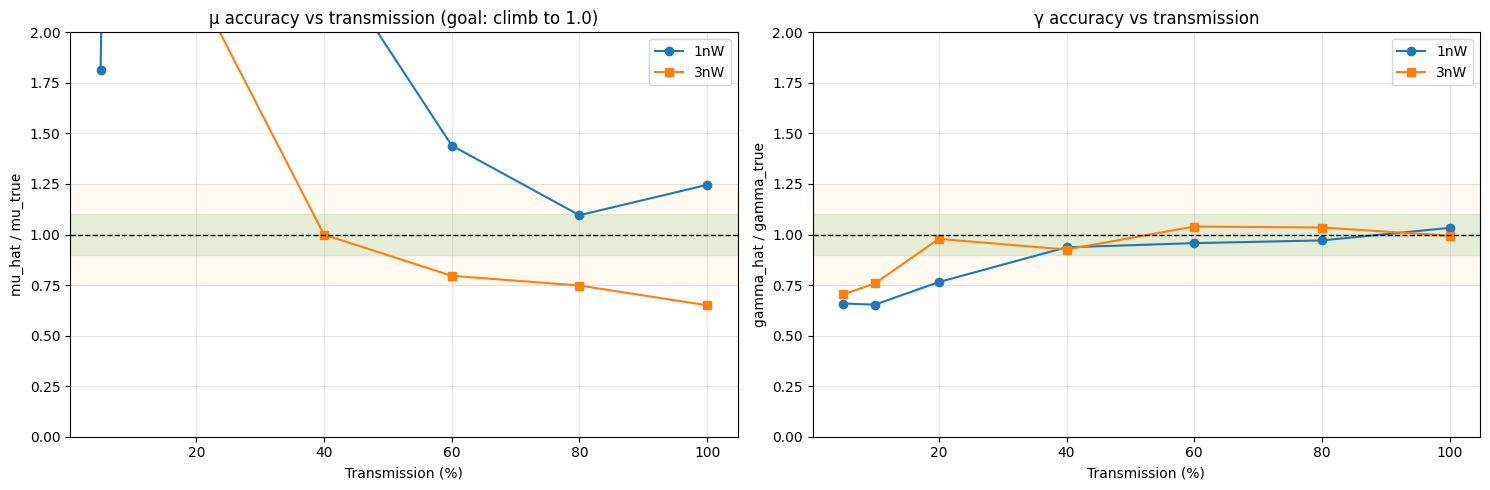

graded-goal check (ratio by transmission):
    T   mu(1nW)   mu(3nW)    g(1nW)    g(3nW)
    5     1.814     7.487     0.659     0.704
   10     9.689     3.881     0.653     0.758
   20      6.77     2.226     0.765     0.978
   40     2.406     0.999     0.937     0.926
   60      1.44     0.796     0.957      1.04
   80     1.096     0.748     0.971     1.035
  100     1.246      0.65     1.033     0.994


In [13]:
# ============================================================
# FIG 4 — accuracy vs transmission (goal: ratios climb toward 1.0 with T)
# ============================================================
pows = ['1nW', '3nW']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, ['mu', 'gamma']):
    for p, mk in zip(pows, ['o-', 's-']):
        rs = sorted([r for r in results if r['power'] == p], key=lambda z: z['T'])
        if not rs: continue
        xs = [r['T'] for r in rs]
        ys = [(r['mu_final']/r['mu_true']) if key == 'mu' else (r['gamma_final']/r['gamma_true']) for r in rs]
        ax.plot(xs, ys, mk, label=p, ms=6)
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.axhspan(0.9, 1.1, color='green', alpha=0.10); ax.axhspan(0.75, 1.25, color='orange', alpha=0.06)
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true'); ax.set_ylim(0, 2.0)
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_title('μ accuracy vs transmission (goal: climb to 1.0)')
axes[1].set_title('γ accuracy vs transmission')
plt.tight_layout(); plt.show()

print('graded-goal check (ratio by transmission):')
print(f"{'T':>5} {'mu(1nW)':>9} {'mu(3nW)':>9} {'g(1nW)':>9} {'g(3nW)':>9}")
for T in sorted({r['T'] for r in results}):
    row = [T]
    for p in pows:
        rs = [r for r in results if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['mu_final']/rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in pows:
        rs = [r for r in results if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['gamma_final']/rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{row[0]:>5} {row[1]:>9} {row[2]:>9} {row[3]:>9} {row[4]:>9}")

## Verdict — a 1-D FWHM-only loss does **not** help mu: the sigma_fit channel is load-bearing

One change vs 22a: the likelihood drops the `sigma_fit` channel (`W = exp(-0.5 (dF/H_F)^2)`; the
gamma-score keeps only the `dF * dFWHM/dgamma` term). Everything else identical (z-scored `loglik_z`
reward, `sigma_prop` score, no clip / no clamps, divergence STOP). **14 experiments, 100x30,
15.0 min, 0 divergences.** `LR_MU_Z` re-calibrated to **2.72** (TARGET_STEP 3.3).

**(a) mu gets much worse, not better.** mu rel-RMSE **342.1%**, rel-bias **+194.6%** — vs 22a's
132.5% / +74.7% (and 21i's 40.6% / +7.3%). The hypothesis that the mismatched sigma channel is
*costing* us mu is **refuted**: removing it is strictly worse.

**(b) Where it breaks — mu runs away UPWARD at low/mid T.**
- 1nW T10 = x9.69 (119.9 vs 12.4), 1nW T20 = x6.77, 3nW T05 = x7.49, 3nW T10 = x3.88.
- High T is fine: 1nW T40–100 = 2.41 / 1.44 / 1.10 / 1.25 ; 3nW T40–100 = 1.00 / 0.80 / 0.75 / 0.65 —
  the regime where the 2-D loss also worked and where the FWHM channel alone is informative.

**(c) gamma is untouched.** gamma rel-RMSE **18.0%** (22a 18.6%); high-T gamma essentially exact
(1nW T100 1.03; 3nW T60/80/100 = 1.04 / 1.03 / 0.99) and low-T under-recovery unchanged
(0.65–0.76, the known FM#6 line-shape deficit). gamma's gradient is pathwise through FWHM, so it does
not need the sigma channel.

**(d) mu is honestly uninformative here too.** Fisher sigma_mu is huge (67–627 MHz), dwarfing the
bias — consistent with the series' information-limit reading.

**Reading.** The sigma_fit channel is the *only live mu gradient* on this data (FM#8): the discrete
count channel is dead, and the **FWHM marginal alone does not identify mu** — without sigma it hands
mu a spurious runaway at low count instead of a usable signal. So the sigma channel is not the villain
to be dropped; the low-mu *attractor* it induces (19c/d) is a symptom of the sigma(**mu**) *shape*
mismatch. The right lever is to fix the sigma shape (post-19d recommendation #2), not to remove the
channel.

**Caveat.** The `NB_SMOKE=1` check (3 exps, N_ITER=5) misleadingly showed mu 6.2% — the tiny-budget run
is neither converged nor predictive (the coupled mu/gamma dynamics are chaotically sensitive), so the
full run is the reading.

**Baseline (22a, 2-D, same setup):** mu 132.5% / +74.7%, gamma 18.6%, 0 divergences.
